In [1]:
import json

import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline

from preprocessing import ChicagoPreprocessor, FEATURES_TO_EXCLUDE, CAT_COLS, TARGET

We load the raw data and only split off the target — all other preprocessing (dropping excluded columns, casting categoricals) now happens inside the pipeline.

In [2]:
raw = pd.read_parquet(r"../Data/sale_and_crime_data/chicago_sales_with_crime.parquet")

y = raw[TARGET]
X = raw.drop(columns=[TARGET])

Build and fit the pipeline with the tuned hyperparameters (produced by `notebooks/Model_tuning.ipynb`). The target is also included in the preprocessor's drop list as a safeguard: if someone later feeds the loaded pipeline a raw frame that still contains `sale_price`, it gets dropped instead of leaking in as a feature.

In [3]:
with open("../notebooks/hyperparameters.json", "r") as f:
    hyperparams = json.load(f)

pipeline = Pipeline([
    ("preprocess", ChicagoPreprocessor(
        drop_cols=FEATURES_TO_EXCLUDE + [TARGET],
        cat_cols=CAT_COLS,
    )),
    ("model", xgb.XGBRegressor(
        random_state=42,
        enable_categorical=True,
        tree_method="hist",
        **hyperparams,
    )),
])

pipeline.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,drop_cols,"['pin', 'is_multisale', ...]"
,cat_cols,"['type_of_residence', 'construction_quality', ...]"
Name,Type,Value
cat_dtypes_,dict,"{'ba...sh': CategoricalDt...ies_dtype=str), 'ba...pe': CategoricalDt...ies_dtype=str), 'ce...ir': CategoricalDt...ies_dtype=str), 'ce...ng': CategoricalDt...ies_dtype=str), ...}"
feature_names_,list,"['year', 'ye...lt', 'bu...ft', 'la...ft', ...]"
,base_score,None
,booster,None


## Feature importance

Same plot as in `Final_results2_tree.ipynb`

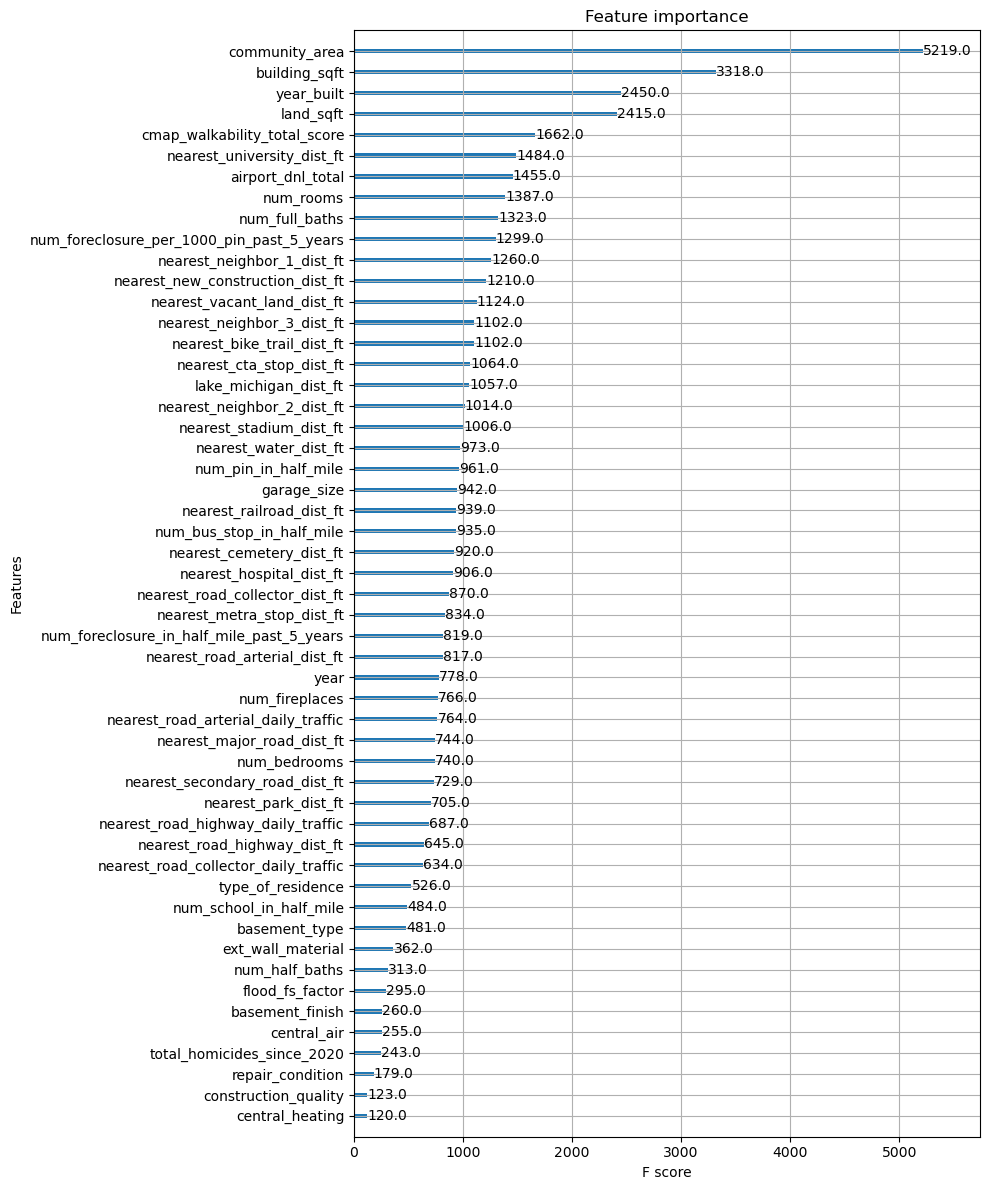

In [4]:
fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(pipeline.named_steps["model"], ax=ax)
plt.tight_layout()
plt.show()

## Serialize

In [ ]:
import sklearn

joblib.dump(pipeline, "final_model.joblib")

print(f"xgboost {xgb.__version__}, scikit-learn {sklearn.__version__}, pandas {pd.__version__}")

xgboost 2.1.4, scikit-learn 1.9.0, pandas 3.0.3


## Reload and verify

In [ ]:
reloaded = joblib.load("final_model.joblib")

sample = raw.head(1000)  # still contains sale_price; the preprocessor drops it
preds_original = pipeline.predict(sample)
preds_reloaded = reloaded.predict(sample)

assert np.array_equal(preds_original, preds_reloaded), "Reloaded predictions differ!"
print("Reloaded pipeline reproduces the original predictions exactly on 1000 sample rows.")

Reloaded pipeline reproduces the original predictions exactly on 1000 sample rows.
First five predictions: [ 113188.36  229654.12 2210943.    277964.47 1080776.2 ]


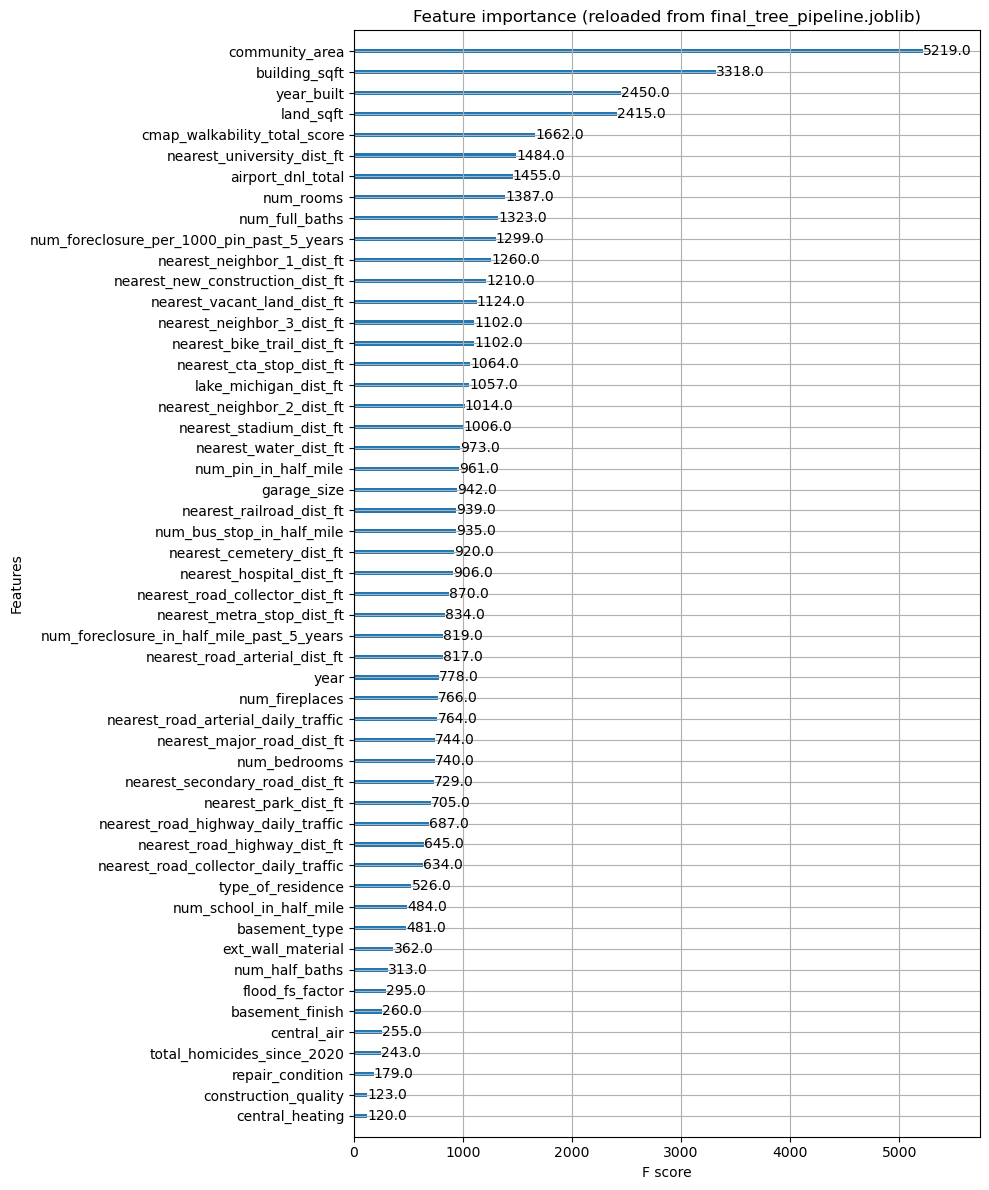

In [7]:
fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(reloaded.named_steps["model"], ax=ax)
ax.set_title("Feature importance (reloaded from final_tree_pipeline.joblib)")
plt.tight_layout()
plt.show()